<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [3]:
# Your code here
college = pd.read_csv('./data/College.csv')

In [5]:
college = college.rename(columns={'Unnamed: 0': 'College'})

In [6]:
college.head()

,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [7]:
college.shape

(777, 19)

In [8]:
college.dtypes

College            str
Private            str
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD                str
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object

In [10]:
college.isnull().sum()

College        0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [21]:
# Your code here
college['PhD'] = pd.to_numeric(college['PhD'], errors='coerce')

In [22]:
college['PhD'] = college['PhD'].clip(upper=100) #remove all entries above 100
college['PhD'] = college['PhD'].fillna(college['PhD'].median()) #impute the removed entries with median

#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [23]:
# Your code here
college['Grad.Rate'] = college['Grad.Rate'].clip(upper = 100)
college['Grad.Rate'] = college['Grad.Rate'].fillna(college['Grad.Rate'].median())

## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [37]:
%%writefile myutils.py
import pandas as pd
import numpy as np

def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """
    # Your code here
    results = []
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        skew_val = df[col].skew()
        abs_skew = abs(skew_val)
        min_val = df[col].min()
        
        # Classification
        if abs_skew < 0.5:
            degree = 'Approximately Symmetric'
        elif abs_skew <= 1.0:
            degree = 'Moderately Skewed'
        else:
            degree = 'Highly Skewed'
            
        direction = 'Positive' if skew_val >= 0 else 'Negative'
        
        # Recommendation
        if degree == 'Approximately Symmetric':
            recommend = 'None needed'
        elif min_val >= 0:
            recommend = 'log(x+1) or Yeo-Johnson' if min_val == 0 else 'Box-Cox or Yeo-Johnson'
        else:
            recommend = 'Yeo-Johnson'
            
        results.append({
            'Feature': col,
            'Skewness': skew_val,
            'Degree': degree,
            'Direction': direction,
            'Recommended Transformation': recommend
        })
        
    return pd.DataFrame(results)

Overwriting myutils.py


In [38]:
# Now import the function from myutils
from myutils import skew_calc

In [49]:
from scipy import stats

def plot_transformations(df, skew_table):
    """
    Applies the recommended transformation to each column, then plots the before and after 
    distributions side by side with the skewness degree on each subplot.
    """
# Your code here
    # Get features that need transformation
    skewed_cols = skew_table[skew_table['Recommended Transformation'] != 'None needed']['Feature']
    
    for col in skewed_cols:
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))       
        # Original distribution
        sns.histplot(df[col], kde=True, ax=axes[0])
        axes[0].set_title(f"Original: {col} (Skew: {df[col].skew():.2f})")
        
        # Transformed distribution
        data_transformed, _ = stats.yeojohnson(df[col]) # using _ to ignore lambda
        skew_transformed = pd.Series(data_transformed).skew()   
        sns.histplot(data_transformed, kde=True, ax=axes[1])
        axes[1].set_title(f"Transformed: {col} (Skew: {skew_transformed:.2f})")
        
        plt.tight_layout()
        plt.show()

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [43]:
# Your code here
skew_calc(college)

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
1,Accept,3.417727,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
2,Enroll,2.690465,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
3,Top10perc,1.413217,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
4,Top25perc,0.259340,Approximately Symmetric,Positive,None needed
5,F.Undergrad,2.610458,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.692353,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
7,Outstate,0.509278,Moderately Skewed,Positive,Box-Cox or Yeo-Johnson
8,Room.Board,0.477356,Approximately Symmetric,Positive,None needed
9,Books,3.485025,Highly Skewed,Positive,Box-Cox or Yeo-Johnson


In [ ]:
# No code here

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
1,Accept,3.417727,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
2,Enroll,2.690465,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
3,Top10perc,1.413217,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
4,Top25perc,0.259340,Approximately Symmetric,Positive,None needed
5,F.Undergrad,2.610458,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.692353,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
7,Outstate,0.509278,Moderately Skewed,Positive,Box-Cox or Yeo-Johnson
8,Room.Board,0.477356,Approximately Symmetric,Positive,None needed
9,Books,3.485025,Highly Skewed,Positive,Box-Cox or Yeo-Johnson


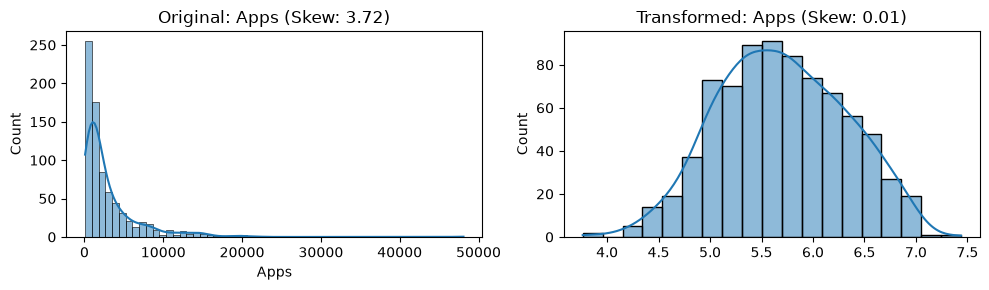

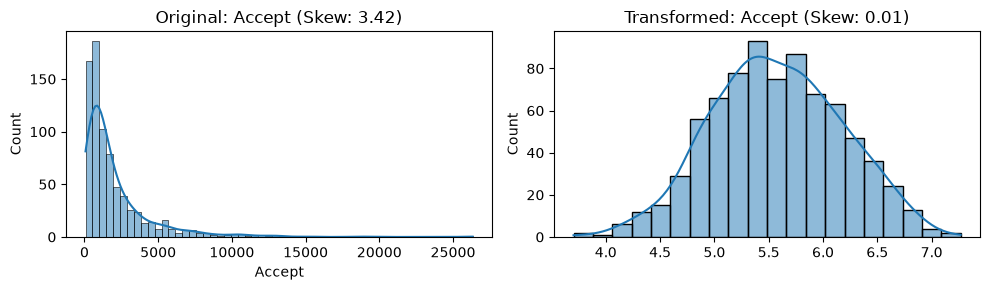

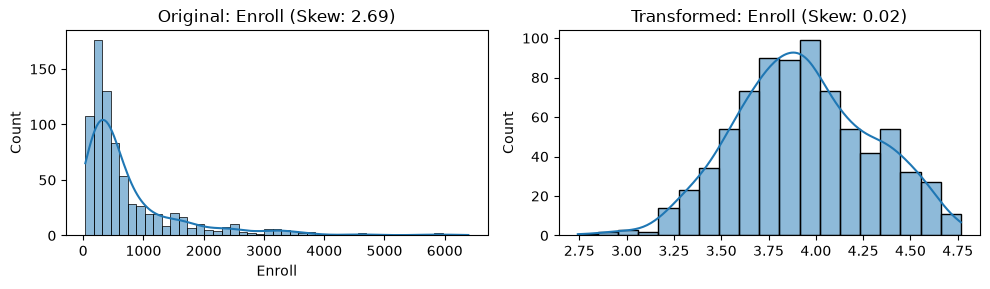

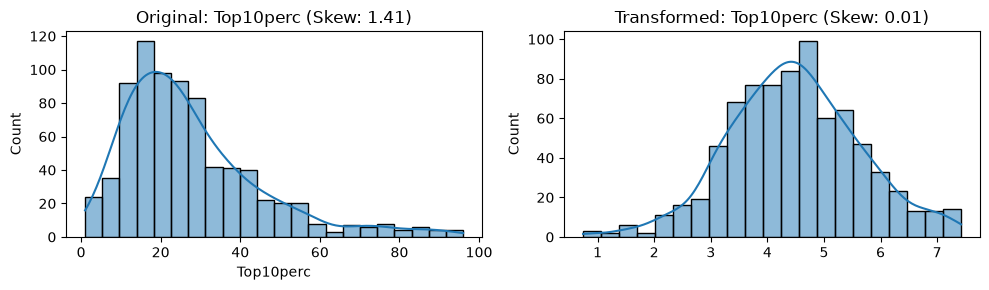

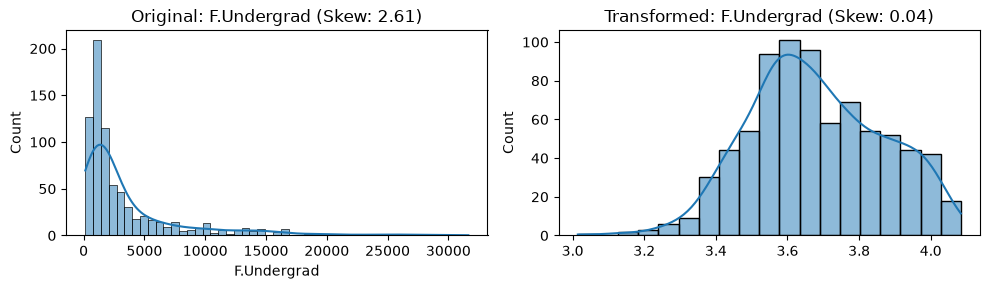

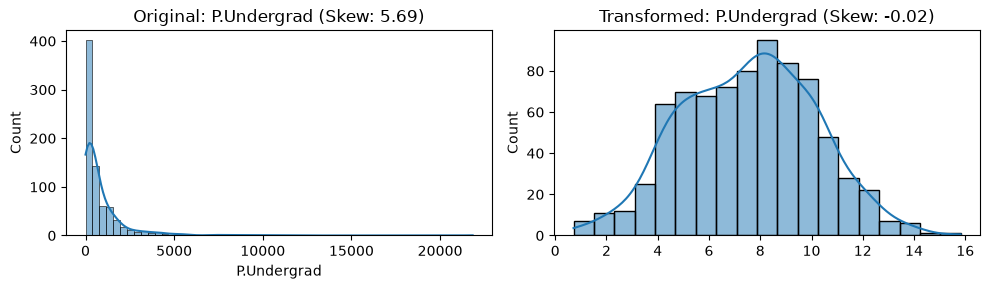

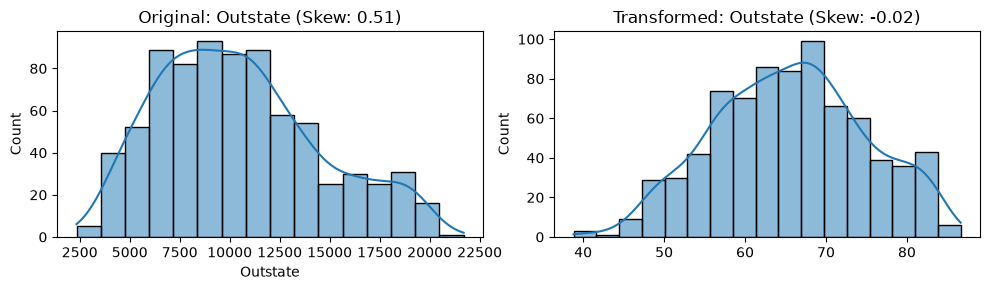

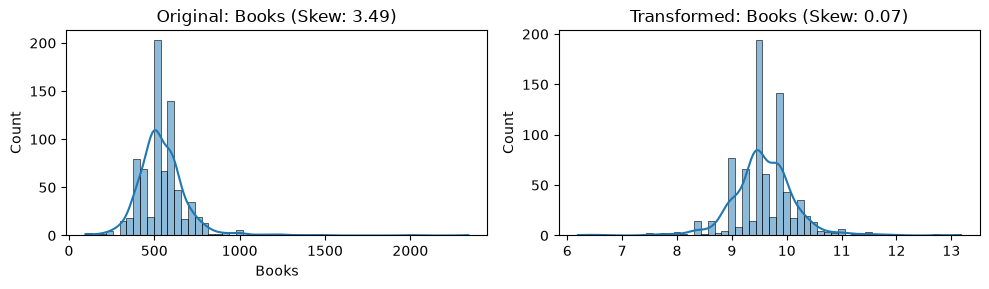

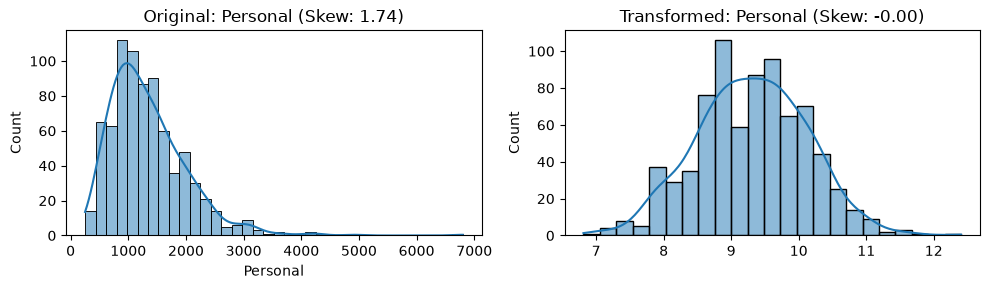

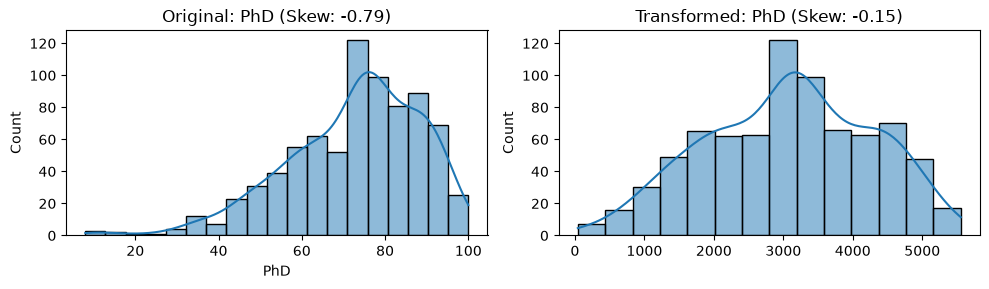

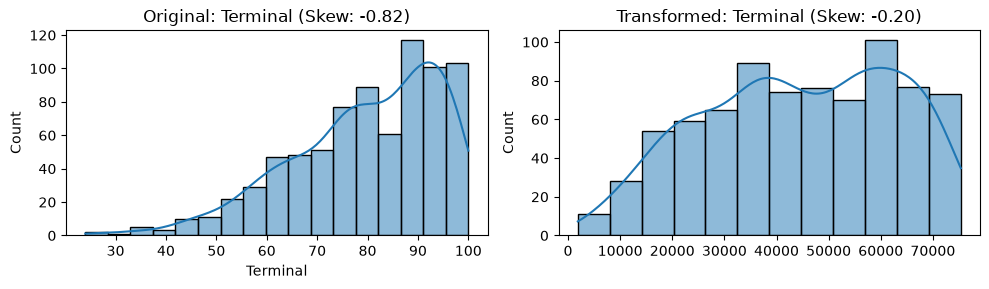

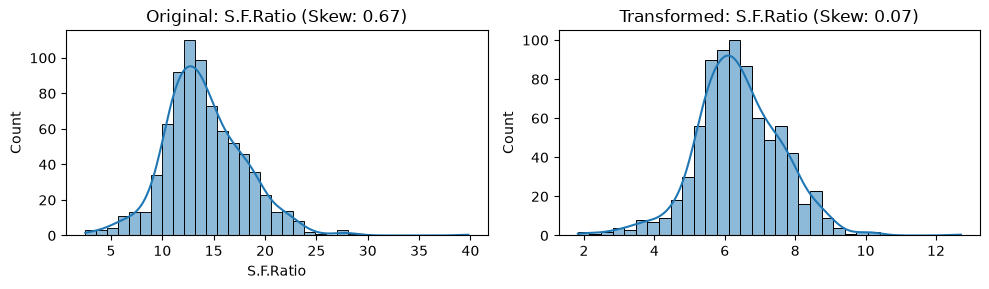

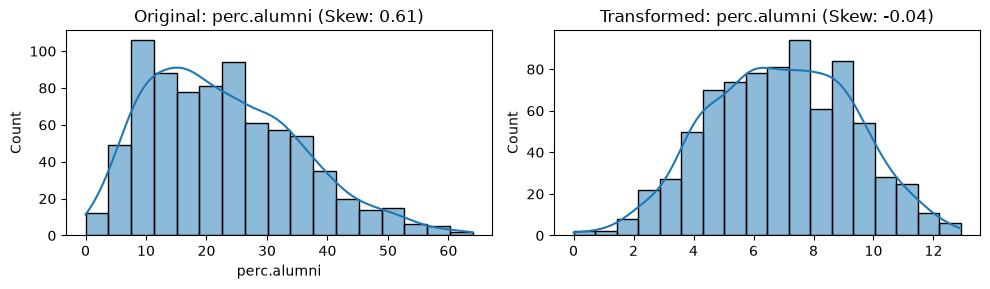

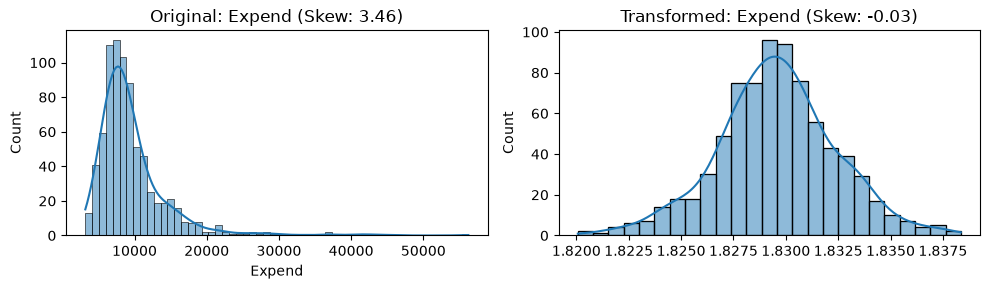

In [50]:
# Your code here
plot_transformations(college, skew_table)

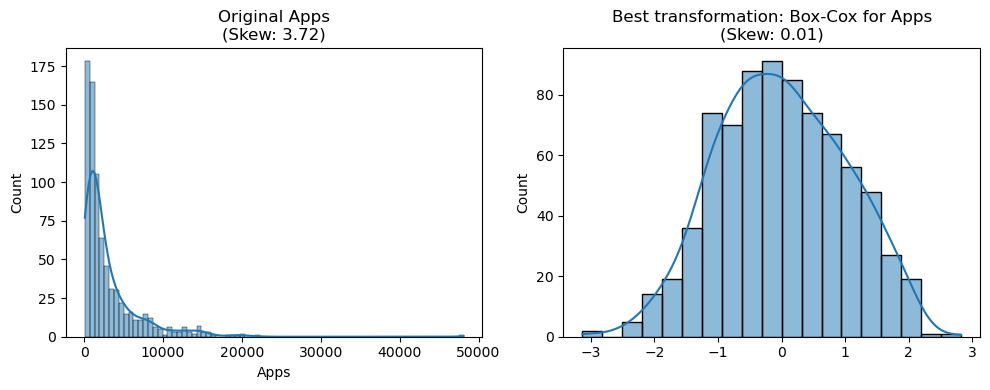

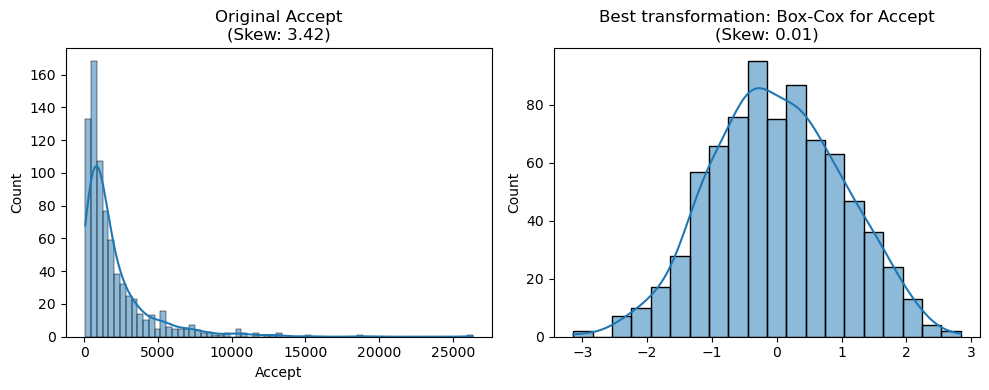

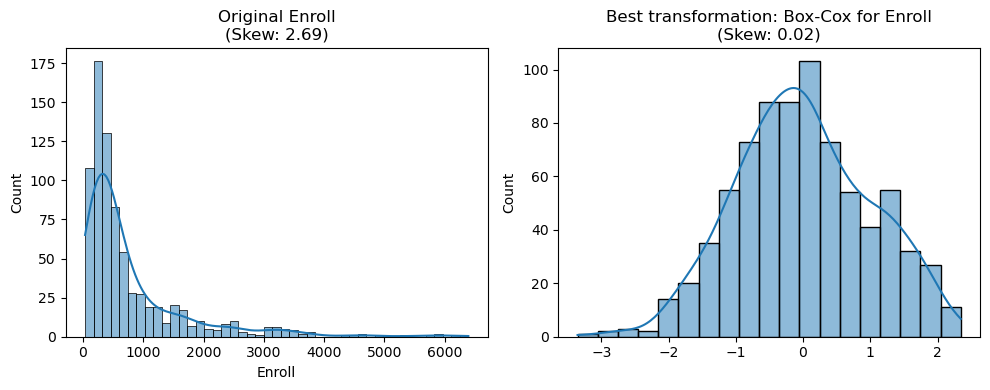

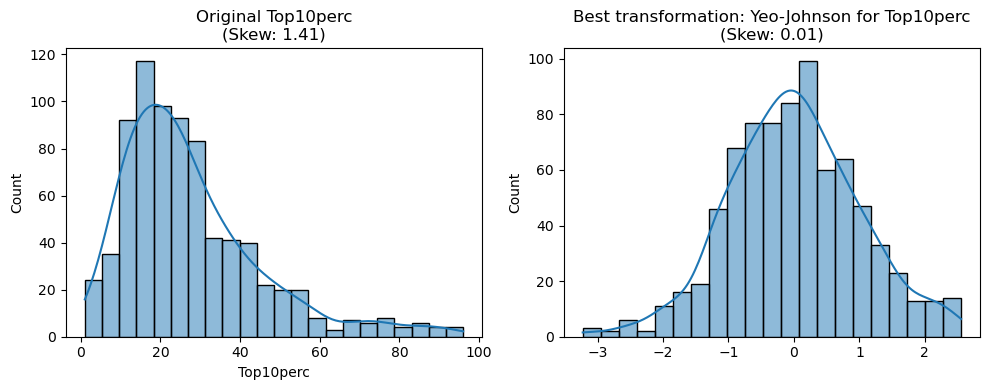

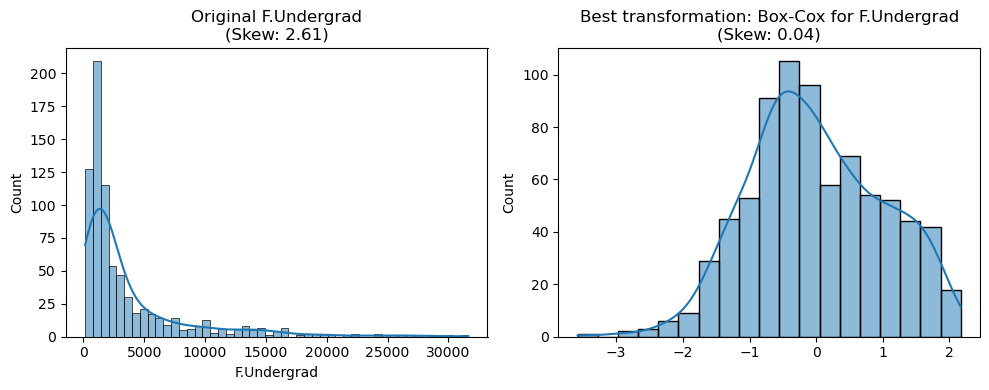

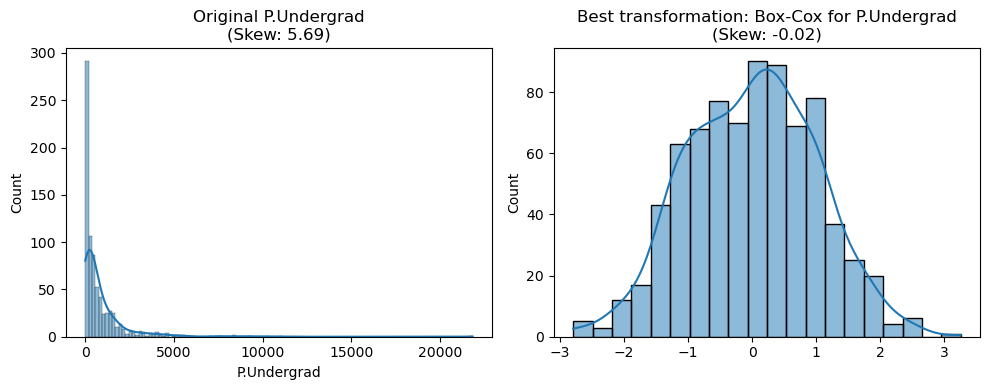

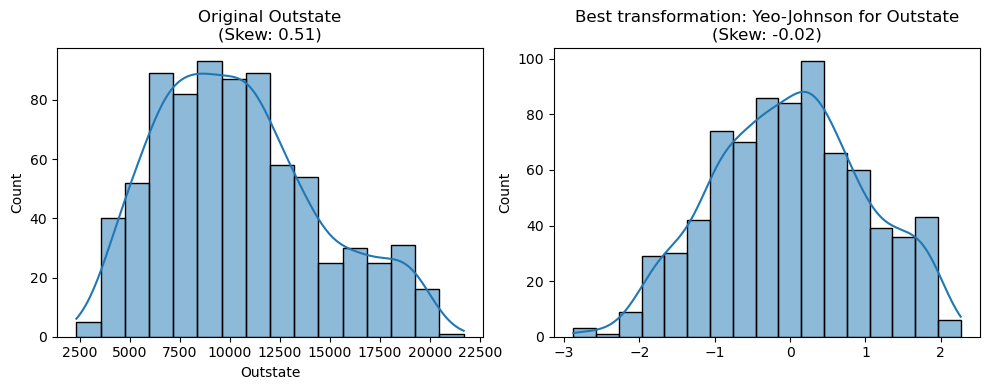

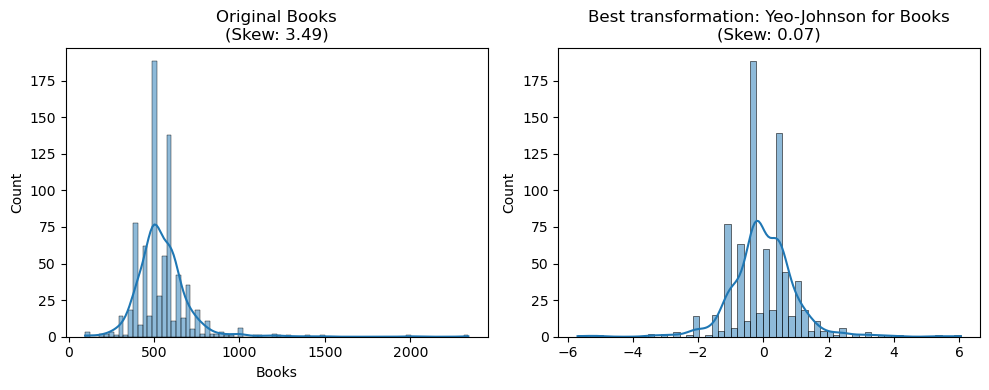

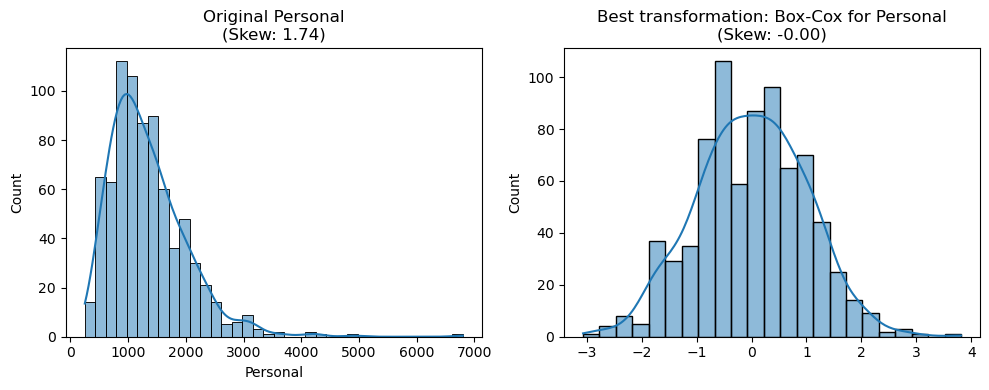

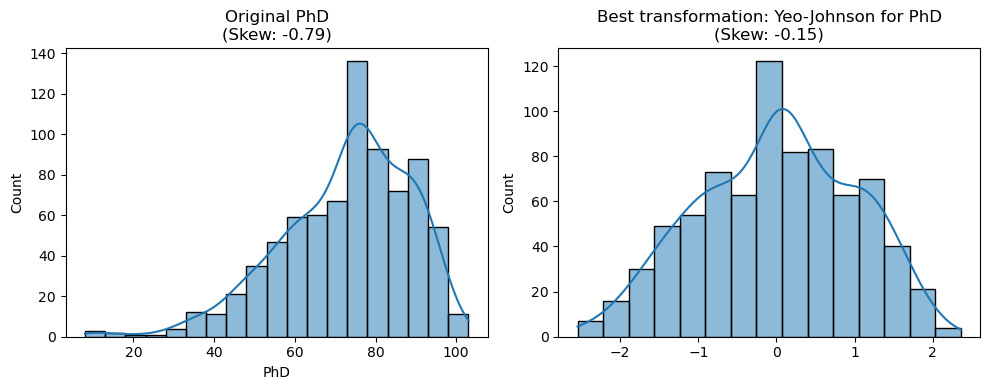

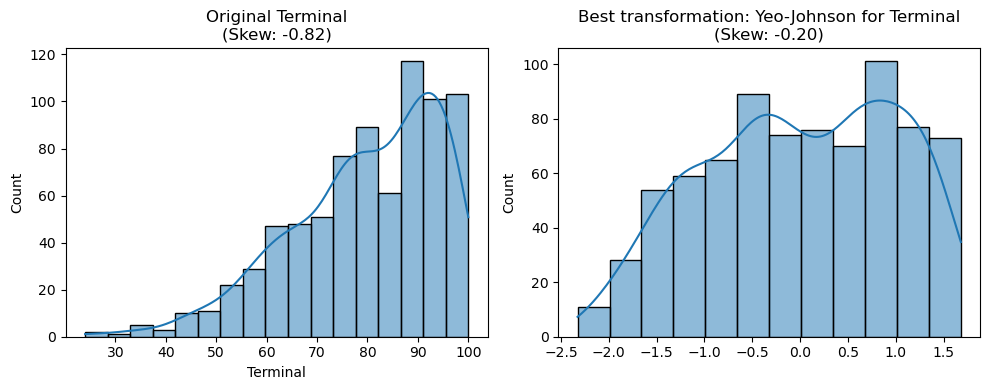

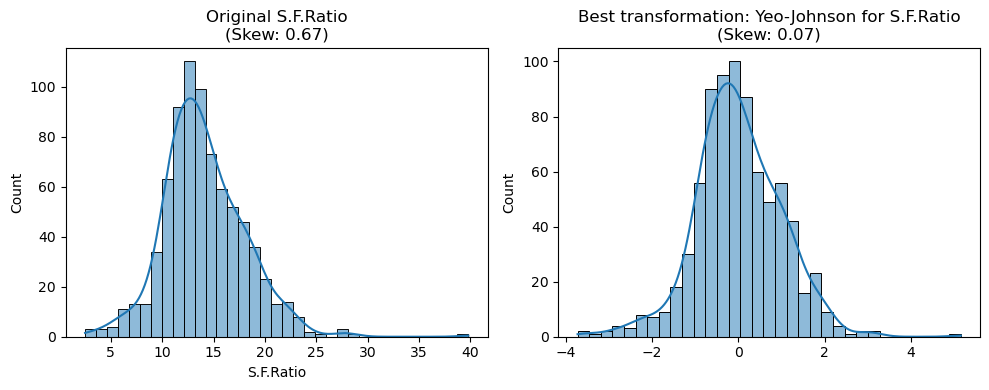

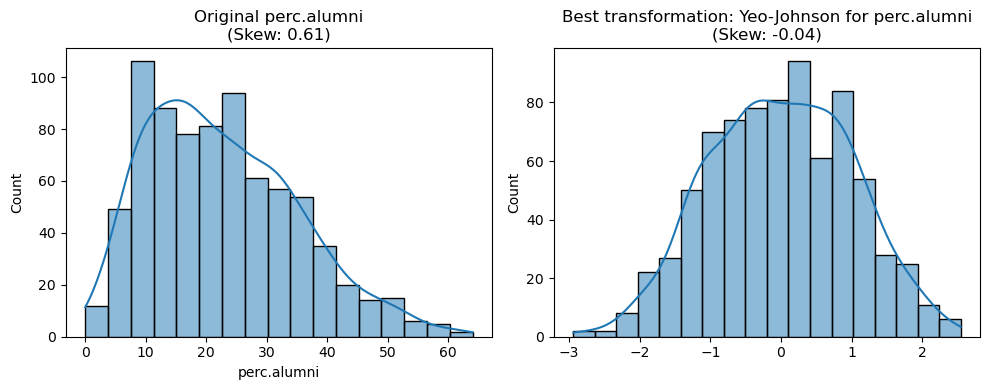

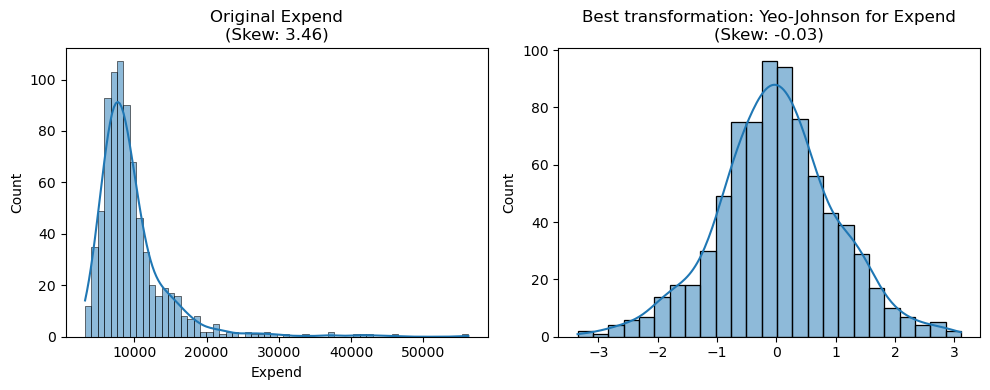

In [ ]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [53]:
trans_cols = []

# Your code here 
skewed_cols = skew_table[skew_table['Recommended Transformation'] != 'None needed']['Feature']

for col in skewed_cols:
    new_col_name = f"{col}_transformed"
    
    # Apply Yeo-Johnson transformation
    college[new_col_name], _ = stats.yeojohnson(college[col])
    
    # Track the new column names in trans_cols
    trans_cols.append(new_col_name)

# Display the first few rows of the newly created columns
college[trans_cols].head()

,Apps_transformed,Accept_transformed,Enroll_transformed,Top10perc_transformed,F.Undergrad_transformed,P.Undergrad_transformed,Outstate_transformed,Books_transformed,Personal_transformed,PhD_transformed,Terminal_transformed,S.F.Ratio_transformed,perc.alumni_transformed,Expend_transformed
0,5.712756,5.598252,4.107319,4.417175,3.760783,8.337244,59.118424,9.213393,10.338539,2725.181328,39361.144632,7.640162,4.953607,1.828169
1,5.870437,5.863990,3.982106,3.793745,3.748081,9.804806,70.749840,10.352803,9.675230,477.500634,3317.836366,5.860981,5.900711,1.831123
2,5.625166,5.527701,3.818676,4.337923,3.561472,5.648714,68.569551,8.961075,9.247663,1567.246931,25461.318422,6.087930,8.505877,1.829832
3,4.871910,4.800383,3.433564,6.332033,3.394972,4.998474,72.124122,9.213393,8.772976,4702.342076,69589.808553,4.254327,9.568133,1.834448
4,4.365717,4.208119,2.985824,3.793745,3.198323,9.179262,59.459747,10.502115,9.675230,3210.734325,31942.302496,5.762129,1.435605,1.831362


## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [57]:
# Your code here 
college['Accept_Rate'] = college['Accept'] / college['Apps']
college[['College','Private','Apps','Accept','Accept_Rate']].head()

,College,Private,Apps,Accept,Accept_Rate
0,Abilene Christian University,Yes,1660,1232,0.742169
1,Adelphi University,Yes,2186,1924,0.880146
2,Adrian College,Yes,1428,1097,0.768207
3,Agnes Scott College,Yes,417,349,0.836930
4,Alaska Pacific University,Yes,193,146,0.756477


#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [62]:
# Your code here 
college['Outstate_Tier'] = pd.cut(college['Outstate'],bins = 3, labels = ['Low','Mid','High'])
college[['College','Private','Outstate','Outstate_Tier']].tail()

,College,Private,Outstate,Outstate_Tier
772,Worcester State College,No,6797,Low
773,Xavier University,Yes,11520,Mid
774,Xavier University of Louisiana,Yes,6900,Low
775,Yale University,Yes,19840,High
776,York College of Pennsylvania,Yes,4990,Low


#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [61]:
# Your code here 
tier_rating = {'Low': 0, 'Mid': 1, 'High': 2}
college['Outstate_Tier_Encoded'] = college['Outstate_Tier'].map(tier_rating)
college[['College','Private','Outstate','Outstate_Tier','Outstate_Tier_Encoded']].tail()

,College,Private,Outstate,Outstate_Tier,Outstate_Tier_Encoded
772,Worcester State College,No,6797,Low,0
773,Xavier University,Yes,11520,Mid,1
774,Xavier University of Louisiana,Yes,6900,Low,0
775,Yale University,Yes,19840,High,2
776,York College of Pennsylvania,Yes,4990,Low,0


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [65]:
# Your code here 
if_private = {'Yes': 1, 'No': 0}
college['Private_Encoded'] = college['Private'].map(if_private)

college[['College', 'Private', 'Private_Encoded']].tail()

,College,Private,Private_Encoded
772,Worcester State College,No,0
773,Xavier University,Yes,1
774,Xavier University of Louisiana,Yes,1
775,Yale University,Yes,1
776,York College of Pennsylvania,Yes,1


## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [66]:
cols_to_scale = []

# Your code here
scaler = StandardScaler()
# Define list of columns to scale
cols_to_scale = trans_cols + ['Accept_Rate', 'Outstate_Tier_Encoded', 'Private_Encoded']

scaled_col_names = [f"{col}_scaled" for col in cols_to_scale]
college[scaled_col_names] = scaler.fit_transform(college[cols_to_scale])
college[scaled_col_names].head()

,Apps_transformed_scaled,Accept_transformed_scaled,Enroll_transformed_scaled,Top10perc_transformed_scaled,F.Undergrad_transformed_scaled,P.Undergrad_transformed_scaled,Outstate_transformed_scaled,Books_transformed_scaled,Personal_transformed_scaled,PhD_transformed_scaled,Terminal_transformed_scaled,S.F.Ratio_transformed_scaled,perc.alumni_transformed_scaled,Expend_transformed_scaled,Accept_Rate_scaled,Outstate_Tier_Encoded_scaled,Private_Encoded_scaled
0,0.027875,0.041123,0.493988,-0.047533,0.433757,0.306487,-0.693452,-0.614325,1.271442,-0.292117,-0.282856,1.019033,-0.834712,-0.491190,-0.032372,-1.098797,0.612553
1,0.283085,0.486070,0.142540,-0.586896,0.365526,0.873163,0.556270,1.302507,0.456594,-2.175248,-2.247872,-0.434462,-0.432329,0.552370,0.906193,0.358140,0.612553
2,-0.113891,-0.077005,-0.316177,-0.116099,-0.636916,-0.731646,0.322012,-1.038801,-0.068655,-1.262247,-1.040649,-0.249057,0.674492,0.096393,0.144750,0.358140,0.612553
3,-1.333051,-1.294811,-1.397108,1.609115,-1.531331,-0.982726,0.703928,-0.614325,-0.651789,1.364369,1.365157,-1.747012,1.125798,1.727003,0.612225,0.358140,0.612553
4,-2.152336,-2.286486,-2.653827,-0.586896,-2.587702,0.631619,-0.656779,1.553695,0.456594,0.114684,-0.687317,-0.515219,-2.329357,0.637052,0.064955,-1.098797,0.612553


#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

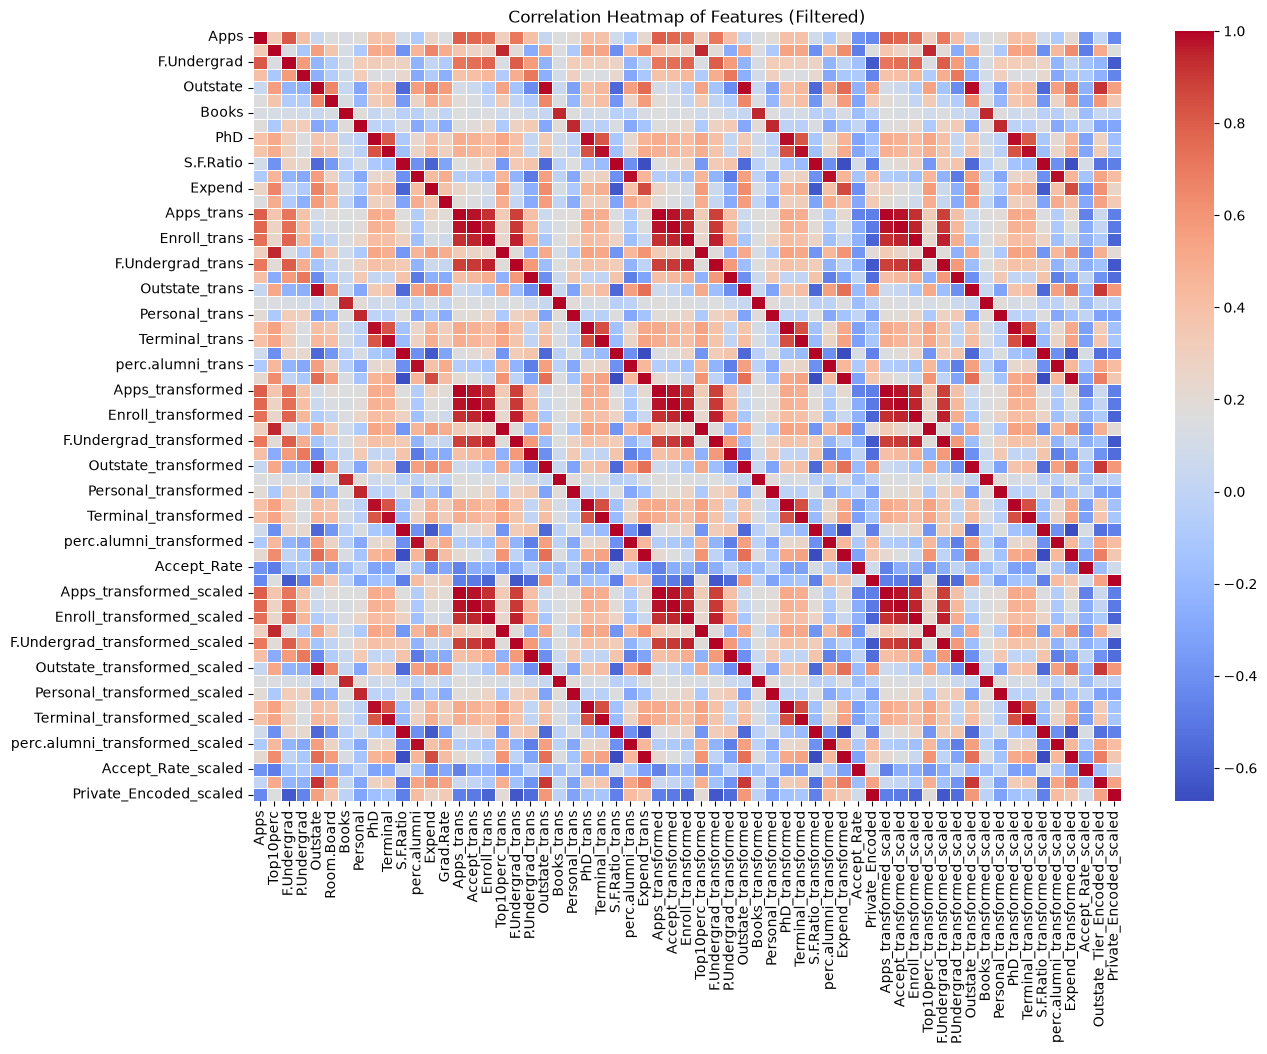

Top correlations with Grad.Rate:
Grad.Rate                         1.000000
Outstate                          0.573612
Outstate_trans                    0.569032
Outstate_transformed              0.569032
Outstate_transformed_scaled       0.569032
Outstate_Tier_Encoded_scaled      0.538930
perc.alumni_transformed           0.500899
perc.alumni_trans                 0.500899
perc.alumni_transformed_scaled    0.500899
Top10perc                         0.498118
Name: Grad.Rate, dtype: float64


In [72]:
# Your code here 
plt.figure(figsize=(14, 10))

# Select numeric columns
numeric_cols = college.select_dtypes(include=[np.number]).columns

# Specify columns you want to exclude from the heatmap
cols_to_exclude = ['Accept', 'Enroll', 'Top25perc', 'Outstate_Tier_Encoded']

# Filter numeric columns for the plot
plot_cols = [col for col in numeric_cols if col not in cols_to_exclude]

# Compute correlation matrix excluding those columns
corr_matrix = college[plot_cols].corr()

# Plotting
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features (Filtered)')
plt.show()

# Print top correlations with Grad.Rate
print("Top correlations with Grad.Rate:")
print(corr_matrix['Grad.Rate'].sort_values(ascending=False).head(10))

As it appeares in the print from the code, the most correlated feature to Grad.Rate is the Outstate. Meaning that higher tuition costs strongly correlate with higher graduation rates, and the second most correlated feature is the perc.alumni donations rates reflect strong school engagement, satisfaction, and alumni success.

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [75]:
# Your code here
untrans_cols = ['Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc', 
                'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board', 
                'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 
                'perc.alumni', 'Expend', 'Private_Encoded']
trans_scaled_cols = [f"{col}_scaled" for col in cols_to_scale]
X_raw = college[untrans_cols]
X_trans = college[trans_scaled_cols]
y = college['Grad.Rate']


X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42)
X_train_trans, X_test_trans, _, _ = train_test_split(
    X_trans, y, test_size=0.2, random_state=42)

#### 15. Fit a linear regression using the raw predictors


In [76]:
# Your code here
model_raw = LinearRegression()
model_raw.fit(X_train_raw, y_train)

y_pred_raw = model_raw.predict(X_test_raw)
r2_raw = r2_score(y_test, y_pred_raw)

print(f"Raw Predictors R^2 Score: {r2_raw:.4f}")

Raw Predictors R^2 Score: 0.5065


#### 16. Fit the same model using the log-transformed predictors

In [77]:
# Your code here 
model_trans = LinearRegression()
model_trans.fit(X_train_trans, y_train)

y_pred_trans = model_trans.predict(X_test_trans)
r2_trans = r2_score(y_test, y_pred_trans)

print(f"Transformed Predictors R^2 Score: {r2_trans:.4f}")

Transformed Predictors R^2 Score: 0.4790


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [78]:
# Your code here 
print(f"Difference:{r2_trans - r2_raw:.4f}")

Difference:-0.0274


No, there is no improvement in the results, its actually the opposite. Transforming and standardizing the features actually resulted in a slightly lower test performance (a decrease of approximately 0.0275 in R^2).

#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [79]:
# Your code here 
college.to_csv('./data/college_transformed.csv', index=False)